In [1]:
import pandas as pd
import numpy as np

# initial analysis of data

In [2]:

df = pd.read_csv("data/HR_data_2.csv")   # or HR_data.csv if needed

# Drop index-like column if present
if "a" in df.columns:
    df = df.drop(columns=["a"])

# Metadata columns
meta_cols = ["Round", "Phase", "Individual", "Puzzler", "Cohort"]

# Add these only if they exist in HR data 2.csv
extra_meta = [c for c in ["Original ID", "raw data Path", "Team ID"] if c in df.columns]
meta_cols = meta_cols + extra_meta

# Self-report columns
questionnaire_cols = [
    "Frustrated", "upset", "hostile", "alert", "ashamed",
    "inspired", "nervous", "attentive", "afraid", "active", "determined"
]

# Physiological feature columns
feature_cols = [c for c in df.columns if c.startswith(("HR_", "TEMP_", "EDA_"))]

meta_df = df[meta_cols].copy()
y_questionnaire = df[[c for c in questionnaire_cols if c in df.columns]].copy()
X_phys = df[feature_cols].copy()

print("Metadata shape:", meta_df.shape)
print("Questionnaire shape:", y_questionnaire.shape)
print("Physiology feature shape:", X_phys.shape)

Metadata shape: (312, 5)
Questionnaire shape: (312, 11)
Physiology feature shape: (312, 51)


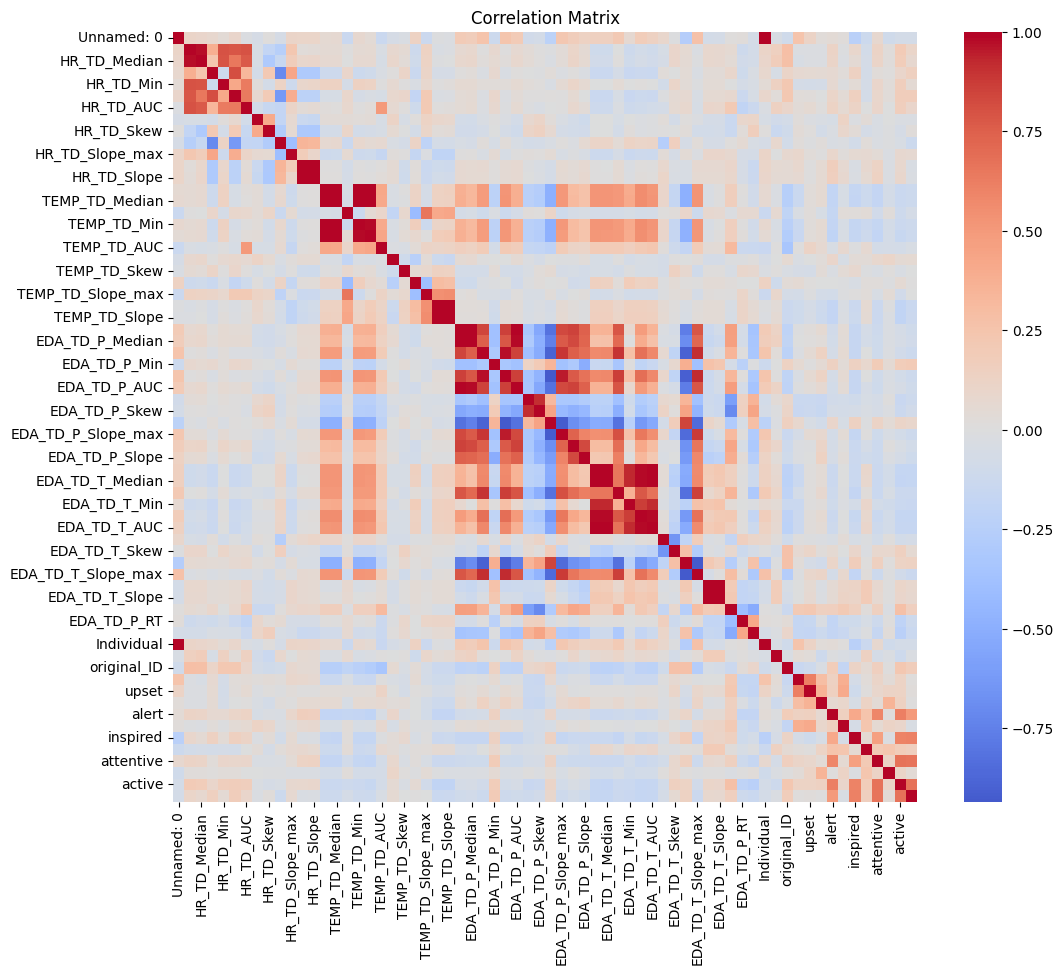

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()


In [4]:
phase_map = {
    "phase1": "pre",
    "phase2": "puzzle",
    "phase3": "post"
}

round_map = {
    "round_1": 1,
    "round_2": 2,
    "round_3": 3,
    "round_4": 4
}

df["Phase_clean"] = df["Phase"].map(phase_map)
df["Round_num"] = df["Round"].map(round_map)

In [5]:
print("Missing per feature")
print(X_phys.isna().sum().sort_values(ascending=False).head(20))

print("Constant features")
constant_phys = [c for c in X_phys.columns if X_phys[c].nunique() <= 1]
print(constant_phys)

print("Near-constant features")
near_constant_phys = [c for c in X_phys.columns if X_phys[c].std(skipna=True) < 1e-8]
print(near_constant_phys)

Missing per feature
EDA_TD_P_ReT           1
EDA_TD_P_RT            1
EDA_TD_T_std           0
EDA_TD_P_Max           0
EDA_TD_P_AUC           0
EDA_TD_P_Kurtosis      0
EDA_TD_P_Skew          0
EDA_TD_P_Slope_min     0
EDA_TD_P_Slope_max     0
EDA_TD_P_Slope_mean    0
EDA_TD_P_Slope         0
EDA_TD_T_Mean          0
EDA_TD_T_Median        0
EDA_TD_T_Min           0
EDA_TD_P_std           0
EDA_TD_T_Max           0
EDA_TD_T_AUC           0
EDA_TD_T_Kurtosis      0
EDA_TD_T_Skew          0
EDA_TD_T_Slope_min     0
dtype: int64
Constant features
[]
Near-constant features
[]


We do median imputation asince there are only numerical values missing and not a lot of them.

In [6]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_proc = preprocess.fit_transform(X_phys)

# run PCA

In [7]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_proc)

explained = pca.explained_variance_ratio_
print(explained[:10])
print("Cumulative variance first 5 PCs:", explained[:5].sum())

[0.27810239 0.10048216 0.08176072 0.06707957 0.05672932 0.0531559
 0.04265791 0.039014   0.030482   0.02575487]
Cumulative variance first 5 PCs: 0.5841541622830957


There is some shared structure in the data
- PC1 explaining almost 28% is not trivial
- so the features are not just pure noise

But the structure is not dominated by one or two very strong directions
- since PC2 drops to around 10%, and first 2 PCs only explain about 39%
- that means a 2D PCA plot may show some tendency, but probably not a super clean separation

The signal is spread across several components
- that fits this dataset well, because the assignment explicitly warns that wearable biosignals are noisy and strongly affected by individual baselines, and the point is to build a sound pipeline and interpret the limitations carefully

The first principal component captures a meaningful but not dominant share of the total variation, while the remaining variation is distributed across the subsequent components. This suggests that the physiological feature space contains some lower-dimensional structure, but that the signal is not reducible to a very small number of dimensions without substantial information loss.

In [8]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Phase": df["Phase_clean"].values,
    "Round": df["Round_num"].values,
    "Individual": df["Individual"].values,
    "Puzzler": df["Puzzler"].values,
    "Cohort": df["Cohort"].values,
    "Frustrated": df["Frustrated"]
})

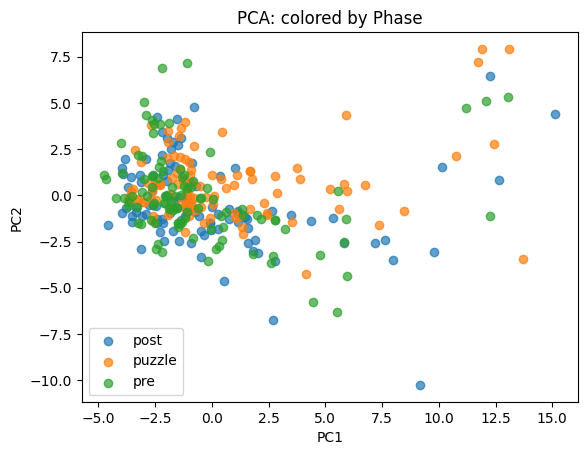

In [9]:
for phase in pca_df["Phase"].unique():
    subset = pca_df[pca_df["Phase"] == phase]
    plt.scatter(subset["PC1"], subset["PC2"], label=phase, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: colored by Phase")
plt.legend()
plt.show()

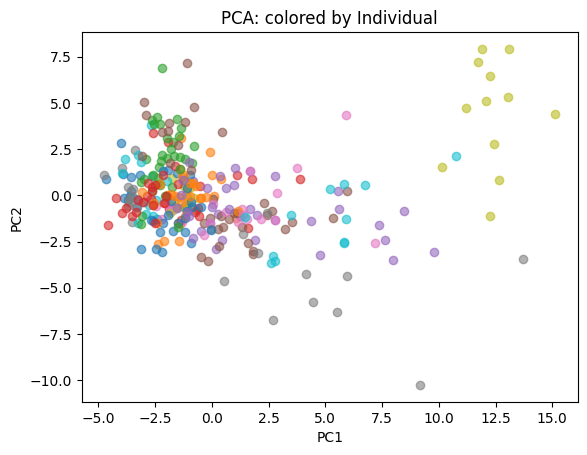

In [10]:
for individual in pca_df["Individual"].unique():
    subset = pca_df[pca_df["Individual"] == individual]
    plt.scatter(subset["PC1"], subset["PC2"], alpha=0.6)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: colored by Individual")
plt.show()

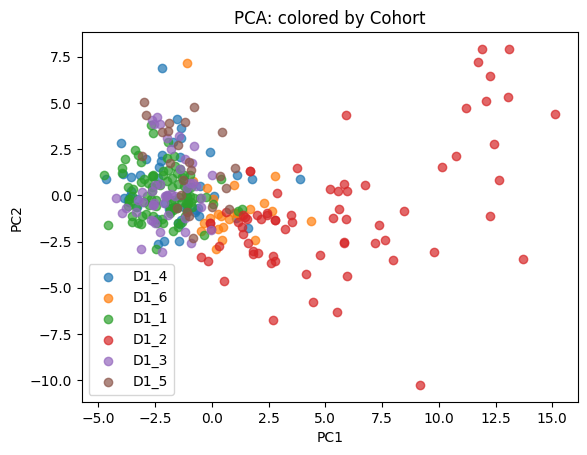

In [11]:
for cohort in pca_df["Cohort"].unique():
    subset = pca_df[pca_df["Cohort"] == cohort]
    plt.scatter(subset["PC1"], subset["PC2"], label=cohort, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: colored by Cohort")
plt.legend()
plt.show()

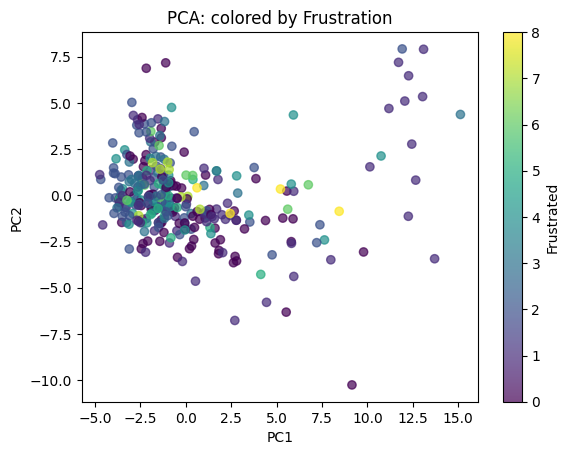

In [12]:
plt.scatter(pca_df["PC1"], pca_df["PC2"], c=pca_df["Frustrated"], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: colored by Frustration")
plt.colorbar(label="Frustrated")
plt.show()

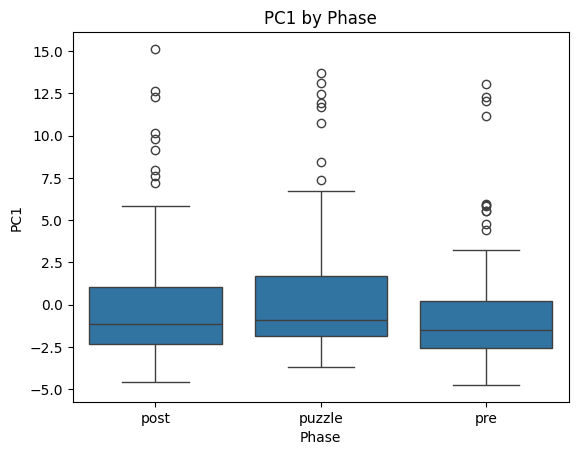

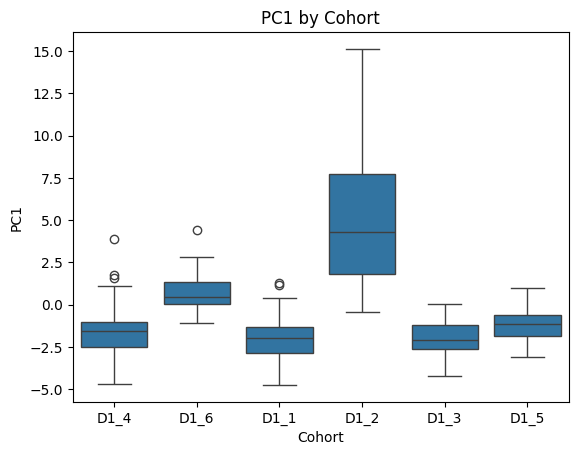

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=pca_df, x="Phase", y="PC1")
plt.title("PC1 by Phase")
plt.show()

sns.boxplot(data=pca_df, x="Cohort", y="PC1")
plt.title("PC1 by Cohort")
plt.show()

In [14]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_phys.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

print(loadings["PC1"].sort_values(key=abs, ascending=False).head(10))
print(loadings["PC2"].sort_values(key=abs, ascending=False).head(10))
print(loadings["PC3"].sort_values(key=abs, ascending=False).head(10))

EDA_TD_P_Max          0.248977
EDA_TD_P_std          0.245851
EDA_TD_T_std          0.240991
EDA_TD_T_Slope_max    0.239388
EDA_TD_P_Slope_max    0.238591
EDA_TD_P_Slope_min   -0.234531
EDA_TD_T_Slope_min   -0.231921
EDA_TD_P_AUC          0.224926
EDA_TD_P_Mean         0.223961
EDA_TD_T_Max          0.215027
Name: PC1, dtype: float64
HR_TD_Max          0.314900
HR_TD_Mean         0.310505
HR_TD_Median       0.285377
HR_TD_AUC          0.280242
EDA_TD_T_Min      -0.253434
HR_TD_std          0.230666
EDA_TD_T_Mean     -0.204661
EDA_TD_T_Median   -0.202782
EDA_TD_T_AUC      -0.199008
HR_TD_Min          0.182304
Name: PC2, dtype: float64
HR_TD_Mean             0.277969
HR_TD_AUC              0.264609
HR_TD_Max              0.259853
HR_TD_Median           0.257554
HR_TD_Min              0.226786
EDA_TD_T_Min           0.216011
EDA_TD_T_Slope_mean    0.208477
EDA_TD_T_Slope         0.205320
TEMP_TD_Max            0.184770
TEMP_TD_Slope          0.178232
Name: PC3, dtype: float64


PC1 is mostly driven by EDA features, especially phasic and tonic spread, maxima, slopes, and phasic AUC. So the main direction in the data looks like a kind of electrodermal activation / variability axis.

PC2 is driven much more by heart-rate level features like HR_TD_Max, HR_TD_Mean, HR_TD_Median, HR_TD_AUC, with some tonic EDA moving in the opposite direction. So PC2 looks more like a heart-rate intensity / baseline axis.

PC3 again has a lot of HR, with some tonic EDA and temperature mixed in, so it seems to capture another physiological variation pattern rather than a clean experimental-state signal.

That fits very well with what you observed in the plots:
- no clear separation by Phase
- some separation for a few Individuals, but not strong overall
- some Cohort separation
- no obvious pattern with Frustrated


But a more intereting point:
The dominant low-dimensional structure seems to reflect physiological variation, especially EDA and HR, but not in a way that cleanly aligns with the experimental phase labels in 2D PCA space.

# Try within-subject centering before PCA.
The assignment itself highlights individual baselines as a central challenge. If baseline physiology differs a lot across participants, raw PCA can mostly reflect those baseline differences instead of phase changes.

So for each physiological feature, subtract that participant’s mean value across all their observations. That gives you a subject-centered dataset and asks:

When baseline level is removed, do phase differences become clearer?

In [15]:
feature_cols = [c for c in df.columns if c.startswith(("HR_", "TEMP_", "EDA_"))]

# subject-centered features
X_centered = df.copy()
X_centered[feature_cols] = (
    df.groupby("Individual")[feature_cols]
      .transform(lambda x: x - x.mean())
)


X_centered_proc = preprocess.fit_transform(X_centered[feature_cols])
pca = PCA()
X_pca = pca.fit_transform(X_centered_proc)

explained = pca.explained_variance_ratio_
print(explained[:10])
print("Cumulative variance first 5 PCs:", explained[:5].sum())

[0.16070714 0.09396913 0.08789204 0.080586   0.07220883 0.05579492
 0.046256   0.04084748 0.03391915 0.02965911]
Cumulative variance first 5 PCs: 0.4953631347384547


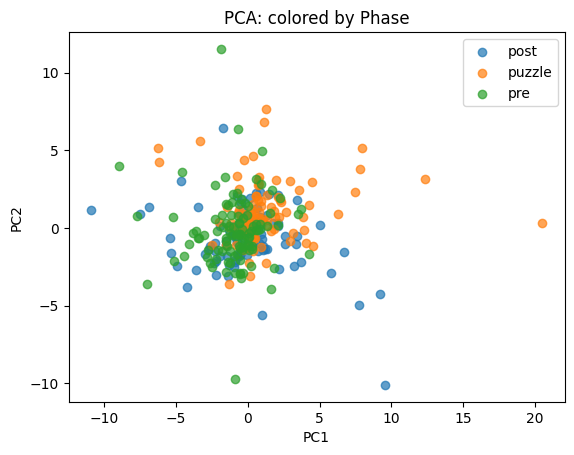

In [16]:

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Phase": df["Phase_clean"].values,
    "Round": df["Round_num"].values,
    "Individual": df["Individual"].values,
    "Puzzler": df["Puzzler"].values,
    "Cohort": df["Cohort"].values,
    "Frustrated": df["Frustrated"]
})

for phase in pca_df["Phase"].unique():
    subset = pca_df[pca_df["Phase"] == phase]
    plt.scatter(subset["PC1"], subset["PC2"], label=phase, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: colored by Phase")
plt.legend()
plt.show()

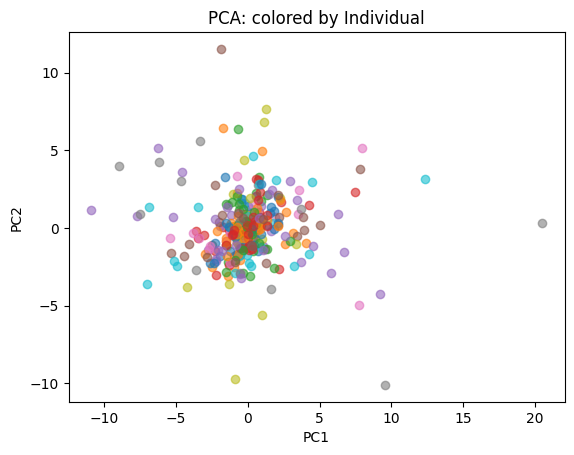

In [17]:
for individual in pca_df["Individual"].unique():
    subset = pca_df[pca_df["Individual"] == individual]
    plt.scatter(subset["PC1"], subset["PC2"], alpha=0.6)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: colored by Individual")
plt.show()

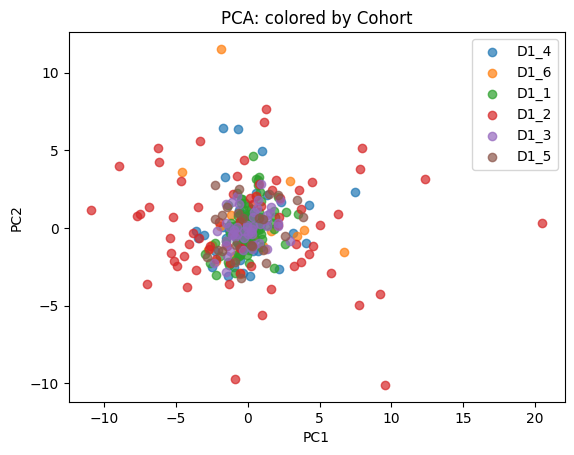

In [18]:
for cohort in pca_df["Cohort"].unique():
    subset = pca_df[pca_df["Cohort"] == cohort]
    plt.scatter(subset["PC1"], subset["PC2"], label=cohort, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: colored by Cohort")
plt.legend()
plt.show()

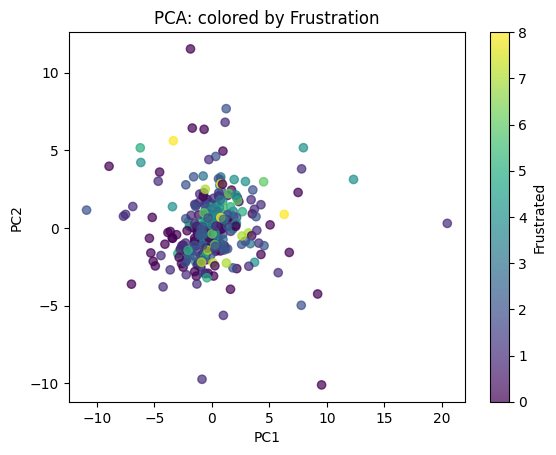

In [19]:
plt.scatter(pca_df["PC1"], pca_df["PC2"], c=pca_df["Frustrated"], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: colored by Frustration")
plt.colorbar(label="Frustrated")
plt.show()

What the centering did was remove some participant-level mean structure, but it did not reveal a clearer phase structure. Since PC1 dropped from about 27.8% to 16.1% and the first 5 PCs dropped from about 58.4% to 49.5%, that suggests some of the original variance was tied to individual baselines, but after removing that, the remaining variation is still spread out and still not aligning clearly with phase.

# try binary classification

phase2 = puzzle

phase1 + phase3 = rest

To what extent do extracted HR, TEMP, and EDA features admit a useful low-dimensional representation for distinguishing puzzle from rest phases across participants?

In [20]:
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
import numpy as np

# only physiological features
feature_cols = [c for c in df.columns if c.startswith(("HR_", "TEMP_", "EDA_"))]

X = df[feature_cols].copy()

# binary target: puzzle vs rest
y = (df["Phase"] == "phase2").astype(int)   # 1 = puzzle, 0 = rest

# grouped CV by participant
groups = df["Individual"]

logo = LeaveOneGroupOut()

pipe_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000))
])

pipe_dummy = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", DummyClassifier(strategy="most_frequent"))
])

scores_lr = cross_val_score(
    pipe_lr, X, y,
    cv=logo.split(X, y, groups=groups),
    scoring="balanced_accuracy"
)

scores_dummy = cross_val_score(
    pipe_dummy, X, y,
    cv=logo.split(X, y, groups=groups),
    scoring="balanced_accuracy"
)

print("LogReg LOSO balanced accuracy:")
print("Mean:", scores_lr.mean())
print("Std:", scores_lr.std())
print("All folds:", scores_lr)

print("\nDummy LOSO balanced accuracy:")
print("Mean:", scores_dummy.mean())
print("Std:", scores_dummy.std())
print("All folds:", scores_dummy)

LogReg LOSO balanced accuracy:
Mean: 0.7091346153846154
Std: 0.17067307692307693
All folds: [0.5    0.6875 0.625  0.875  0.75   0.375  0.875  0.6875 0.875  0.6875
 0.75   0.75   0.9375 0.8125 1.     0.6875 0.875  0.625  0.5    0.5
 0.75   0.9375 0.5625 0.75   0.3125 0.75  ]

Dummy LOSO balanced accuracy:
Mean: 0.5
Std: 0.0
All folds: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


A mean balanced accuracy of 0.709 against a dummy baseline of 0.500 means the physiological features do contain generalizable puzzle-vs-rest signal across unseen participants, even though the first PCA plots did not show clean visual separation.

- 0.709 balanced accuracy is meaningfully above chance.
- The dummy model at 0.500 confirms that this is not just class imbalance.
- The fold variability is large, with some folds near chance and others very high, so the signal is not equally strong for all participants. That fits the case description very well, because the dataset is noisy and strongly affected by inter-subject variability and individual baselines

In [21]:
from sklearn.dummy import DummyClassifier

pipe_raw_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000))
])

pipe_pca_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10)),
    ("clf", LogisticRegression(max_iter=5000))
])

pipe_dummy = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", DummyClassifier(strategy="most_frequent"))
])

models = {
    "Raw + LogReg": pipe_raw_lr,
    "PCA(10) + LogReg": pipe_pca_lr,
    "Dummy": pipe_dummy
}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=logo.split(X, y, groups=groups),
        scoring="balanced_accuracy"
    )
    print(f"\n{name}")
    print("Mean:", scores.mean())
    print("Std :", scores.std())
    print("All folds:", scores)


Raw + LogReg
Mean: 0.7091346153846154
Std : 0.17067307692307693
All folds: [0.5    0.6875 0.625  0.875  0.75   0.375  0.875  0.6875 0.875  0.6875
 0.75   0.75   0.9375 0.8125 1.     0.6875 0.875  0.625  0.5    0.5
 0.75   0.9375 0.5625 0.75   0.3125 0.75  ]

PCA(10) + LogReg
Mean: 0.7139423076923077
Std : 0.15713506726350207
All folds: [0.5    0.75   1.     0.875  0.625  0.5625 0.875  0.75   0.625  0.6875
 1.     0.5625 0.8125 0.5625 0.9375 0.75   0.875  0.625  0.5625 0.75
 0.5625 0.875  0.625  0.6875 0.375  0.75  ]

Dummy
Mean: 0.5
Std : 0.0
All folds: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


In [22]:
pipe_pca_lr.fit(X, y)

pca = pipe_pca_lr.named_steps["pca"]
clf = pipe_pca_lr.named_steps["clf"]

# Coefficients in PCA space
coef_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(10)],
    "Coefficient": clf.coef_[0]
})

print(coef_df.sort_values("Coefficient", key=np.abs, ascending=False))

     PC  Coefficient
3   PC4     0.867215
6   PC7    -0.482900
8   PC9     0.412124
9  PC10    -0.366034
1   PC2     0.314640
4   PC5     0.240175
2   PC3    -0.132430
7   PC8     0.123948
5   PC6     0.088336
0   PC1     0.076764


The important interpretation is:

- PCA was useful for exploration, because it showed the dominant variance structure and helped you see that phase separation is not visually clean.
- Raw features work better for discrimination, which means the class-relevant information is not mainly sitting in the top-variance directions.
- PC4 having the largest logistic coefficient supports that idea. The classifier is relying more on a later PC than on PC1. So the best class-separating direction is not the same as the direction with the most variance.

In [23]:
pipe_raw_lr.fit(X, y)

coefs_raw = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": pipe_raw_lr.named_steps["clf"].coef_[0]
})

coefs_raw["AbsCoefficient"] = coefs_raw["Coefficient"].abs()
coefs_raw = coefs_raw.sort_values("AbsCoefficient", ascending=False)

print(coefs_raw.head(20))

                Feature  Coefficient  AbsCoefficient
38         EDA_TD_T_std    -1.595493        1.595493
48       EDA_TD_P_Peaks     1.455156        1.455156
28         EDA_TD_P_Max     1.024737        1.024737
41         EDA_TD_T_AUC     0.868688        0.868688
21    TEMP_TD_Slope_max    -0.609572        0.609572
8       HR_TD_Slope_min     0.589292        0.589292
14          TEMP_TD_std    -0.566477        0.566477
40         EDA_TD_T_Max    -0.538334        0.538334
32   EDA_TD_P_Slope_min     0.532776        0.532776
34  EDA_TD_P_Slope_mean     0.476926        0.476926
5             HR_TD_AUC     0.446577        0.446577
37      EDA_TD_T_Median    -0.424520        0.424520
42    EDA_TD_T_Kurtosis     0.378056        0.378056
6        HR_TD_Kurtosis    -0.362553        0.362553
47       EDA_TD_T_Slope     0.346209        0.346209
43        EDA_TD_T_Skew     0.338618        0.338618
20    TEMP_TD_Slope_min     0.336263        0.336263
27         EDA_TD_P_Min     0.316939        0.

In [24]:
# map the standardized features back:

pipe_pca_lr.fit(X, y)

pca = pipe_pca_lr.named_steps["pca"]
clf = pipe_pca_lr.named_steps["clf"]

# Back-project coefficients from PC space to scaled feature space
feature_weights = pca.components_.T @ clf.coef_[0]

coef_backproj = pd.DataFrame({
    "Feature": X.columns,
    "Weight_from_PCA_model": feature_weights
})

coef_backproj["AbsWeight"] = coef_backproj["Weight_from_PCA_model"].abs()
coef_backproj = coef_backproj.sort_values("AbsWeight", ascending=False)

print(coef_backproj.head(20)) 

                Feature  Weight_from_PCA_model  AbsWeight
48       EDA_TD_P_Peaks               0.416953   0.416953
49          EDA_TD_P_RT              -0.368368   0.368368
50         EDA_TD_P_ReT              -0.367711   0.367711
14          TEMP_TD_std              -0.362151   0.362151
30    EDA_TD_P_Kurtosis              -0.340045   0.340045
21    TEMP_TD_Slope_max              -0.331648   0.331648
31        EDA_TD_P_Skew              -0.331078   0.331078
20    TEMP_TD_Slope_min               0.321436   0.321436
7            HR_TD_Skew              -0.259743   0.259743
47       EDA_TD_T_Slope               0.221347   0.221347
46  EDA_TD_T_Slope_mean               0.220425   0.220425
6        HR_TD_Kurtosis              -0.190492   0.190492
23        TEMP_TD_Slope              -0.168304   0.168304
5             HR_TD_AUC               0.166973   0.166973
22   TEMP_TD_Slope_mean              -0.155657   0.155657
17          TEMP_TD_AUC               0.155212   0.155212
27         EDA

In [25]:
# sweep across differint number of PCs

from sklearn.model_selection import cross_val_score, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

logo = LeaveOneGroupOut()
groups = df["Individual"]

for k in [2, 3, 5, 8, 10, 15, 20]:
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=k)),
        ("clf", LogisticRegression(max_iter=5000))
    ])
    
    scores = cross_val_score(
        pipe, X, y,
        cv=logo.split(X, y, groups=groups),
        scoring="balanced_accuracy"
    )
    
    print(f"PCA({k}) -> mean={scores.mean():.3f}, std={scores.std():.3f}")

PCA(2) -> mean=0.498, std=0.050
PCA(3) -> mean=0.498, std=0.050
PCA(5) -> mean=0.639, std=0.163
PCA(8) -> mean=0.690, std=0.155
PCA(10) -> mean=0.714, std=0.157
PCA(15) -> mean=0.688, std=0.144
PCA(20) -> mean=0.700, std=0.132


# improving the PCA hopefully

In [26]:
# PCA on within-round changes instead of raw rows
import pandas as pd
import numpy as np

# physiological features only
feature_cols = [c for c in df.columns if c.startswith(("HR_", "TEMP_", "EDA_"))]

# keep one baseline row per Individual x Round from phase1
baseline = (
    df[df["Phase"] == "phase1"][["Individual", "Round"] + feature_cols]
    .drop_duplicates(subset=["Individual", "Round"])
    .rename(columns={c: f"{c}_base" for c in feature_cols})
)

# merge baseline back onto all rows
delta_df = df.merge(baseline, on=["Individual", "Round"], how="left")

# create delta features: current phase minus phase1 baseline
for c in feature_cols:
    delta_df[f"{c}_delta"] = delta_df[c] - delta_df[f"{c}_base"]

delta_cols = [f"{c}_delta" for c in feature_cols]

print(delta_df[["Individual", "Round", "Phase"] + delta_cols[:5]].head())
print("Number of delta features:", len(delta_cols))

   Individual    Round   Phase  HR_TD_Mean_delta  HR_TD_Median_delta  \
0           1  round_3  phase3          0.490314               -1.22   
1           1  round_3  phase2         -1.632831               -1.31   
2           1  round_3  phase1          0.000000                0.00   
3           1  round_2  phase3         -2.303573                1.06   
4           1  round_2  phase2        -13.096011               -9.91   

   HR_TD_std_delta  HR_TD_Min_delta  HR_TD_Max_delta  
0         4.798788            -4.97             9.68  
1        -0.096499            -2.40            -0.47  
2         0.000000             0.00             0.00  
3        -4.667218            -4.33           -36.51  
4        -8.837055            -8.80           -52.65  
Number of delta features: 51


/var/folders/ff/vmrxzkcd2rgfd982bvc157q40000gn/T/ipykernel_34808/140659006.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  delta_df[f"{c}_delta"] = delta_df[c] - delta_df[f"{c}_base"]
/var/folders/ff/vmrxzkcd2rgfd982bvc157q40000gn/T/ipykernel_34808/140659006.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  delta_df[f"{c}_delta"] = delta_df[c] - delta_df[f"{c}_base"]


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, RobustScaler
from sklearn.decomposition import PCA

X_delta = delta_df[delta_cols].copy()

pipe_delta_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", RobustScaler()),
    ("pca", PCA())
])

X_delta_pca = pipe_delta_pca.fit_transform(X_delta)
pca_delta = pipe_delta_pca.named_steps["pca"]

print("Explained variance first 10 PCs:")
print(pca_delta.explained_variance_ratio_[:10])
print("Cumulative first 5 PCs:", pca_delta.explained_variance_ratio_[:5].sum())

Explained variance first 10 PCs:
[0.30257238 0.22548369 0.1251711  0.08537114 0.05885485 0.03652617
 0.02506564 0.01817984 0.01678451 0.01507826]
Cumulative first 5 PCs: 0.7974531485832566


In [28]:
# computing loadings

import numpy as np
import pandas as pd

# Number of PCs
n_pcs = pca_delta.n_components_

pc_names = [f"PC{i+1}" for i in range(n_pcs)]

# 1) Component weights
component_weights = pd.DataFrame(
    pca_delta.components_.T,
    index=delta_cols,
    columns=pc_names
)

# 2) PCA loadings
# Common definition: eigenvectors * sqrt(eigenvalues)
loadings = pd.DataFrame(
    pca_delta.components_.T * np.sqrt(pca_delta.explained_variance_),
    index=delta_cols,
    columns=pc_names
)

print("Component weights:")
print(component_weights.head())

print("\nLoadings:")
print(loadings.head())

for pc in ["PC1", "PC2", "PC3"]:
    print(f"\nTop positive loadings for {pc}:")
    print(loadings[pc].sort_values(ascending=False).head(10))
    
    print(f"\nTop negative loadings for {pc}:")
    print(loadings[pc].sort_values(ascending=True).head(10))
    
    print(f"\nTop absolute loadings for {pc}:")
    print(loadings[pc].sort_values(key=np.abs, ascending=False).head(10))

pc = "PC1"

pc1_table = pd.DataFrame({
    "Feature": loadings.index,
    "Loading": loadings[pc].values,
    "AbsLoading": np.abs(loadings[pc].values)
}).sort_values("AbsLoading", ascending=False)

print(pc1_table.head(20))

Component weights:
                         PC1       PC2       PC3       PC4       PC5  \
HR_TD_Mean_delta   -0.006411  0.009145 -0.003346  0.018479  0.001832   
HR_TD_Median_delta -0.004516  0.015049  0.003030  0.017749 -0.001722   
HR_TD_std_delta    -0.024358 -0.011429 -0.003178  0.033284  0.026028   
HR_TD_Min_delta     0.002458  0.009546 -0.011228  0.002683 -0.010681   
HR_TD_Max_delta    -0.015271 -0.005195 -0.007985  0.027455  0.008784   

                         PC6       PC7       PC8       PC9      PC10  ...  \
HR_TD_Mean_delta   -0.004171 -0.116500  0.239509 -0.131493 -0.118796  ...   
HR_TD_Median_delta -0.016483 -0.134125  0.259776 -0.162689 -0.138351  ...   
HR_TD_std_delta     0.047018 -0.118796  0.430841 -0.191757 -0.175106  ...   
HR_TD_Min_delta    -0.017217 -0.084170  0.069432 -0.029347 -0.039947  ...   
HR_TD_Max_delta     0.030928 -0.117054  0.347365 -0.120643 -0.122938  ...   

                        PC42      PC43      PC44      PC45      PC46  \
HR_TD_Mean_de

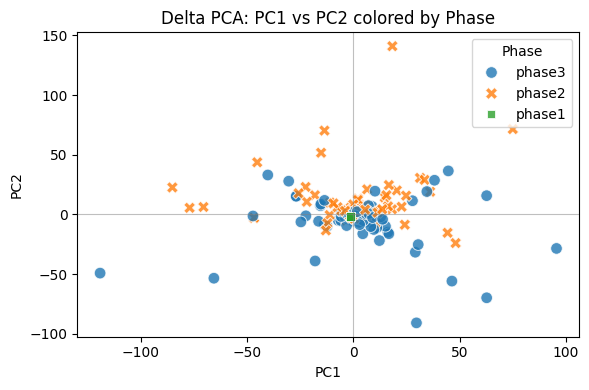

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

pca_plot_df = delta_df[["Phase", "Individual", "Round", "Cohort", "Puzzler"]].copy()
pca_plot_df["PC1"] = X_delta_pca[:, 0]
pca_plot_df["PC2"] = X_delta_pca[:, 1]
pca_plot_df["PC3"] = X_delta_pca[:, 2]

plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="Phase",
    style="Phase",
    alpha=0.8,
    s=70
)
plt.title("Delta PCA: PC1 vs PC2 colored by Phase")
plt.axhline(0, color="gray", linewidth=0.8, alpha=0.5)
plt.axvline(0, color="gray", linewidth=0.8, alpha=0.5)
plt.legend(title="Phase")
plt.tight_layout()
plt.show()

In [30]:
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score
from sklearn.linear_model import LogisticRegression

# use only puzzle and post rows
delta_cls = delta_df[delta_df["Phase"].isin(["phase2", "phase3"])].copy()

X_cls = delta_cls[delta_cols].copy()
y_cls = (delta_cls["Phase"] == "phase2").astype(int)   # 1 = puzzle, 0 = post
groups_cls = delta_cls["Individual"]

logo = LeaveOneGroupOut()

pipe_delta_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", RobustScaler()),
    ("clf", LogisticRegression(max_iter=5000))
])

scores_delta_lr = cross_val_score(
    pipe_delta_lr,
    X_cls,
    y_cls,
    cv=logo.split(X_cls, y_cls, groups=groups_cls),
    scoring="balanced_accuracy"
)

print("Delta features: phase2 vs phase3")
print("Mean:", scores_delta_lr.mean())
print("Std :", scores_delta_lr.std())
print("All folds:", scores_delta_lr)

Delta features: phase2 vs phase3
Mean: 0.6971153846153846
Std : 0.16324929659951581
All folds: [0.5   0.75  0.625 1.    0.75  0.5   0.75  0.75  0.75  0.375 0.75  0.75
 0.75  0.625 0.875 0.625 0.75  0.625 0.625 0.625 0.875 1.    0.75  0.75
 0.25  0.75 ]


In [31]:
pipe_delta_pca_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", RobustScaler()),
    ("pca", PCA(n_components=5)),
    ("clf", LogisticRegression(max_iter=5000))
])

scores_delta_pca_lr = cross_val_score(
    pipe_delta_pca_lr,
    X_cls,
    y_cls,
    cv=logo.split(X_cls, y_cls, groups=groups_cls),
    scoring="balanced_accuracy"
)

print("Delta features + PCA(5): phase2 vs phase3")
print("Mean:", scores_delta_pca_lr.mean())
print("Std :", scores_delta_pca_lr.std())
print("All folds:", scores_delta_pca_lr)

Delta features + PCA(5): phase2 vs phase3
Mean: 0.6298076923076923
Std : 0.1449501291507821
All folds: [0.5   0.625 0.625 1.    0.875 0.5   0.625 0.5   0.5   0.625 0.75  0.625
 0.5   0.5   0.625 0.625 0.625 0.875 0.75  0.75  0.75  0.5   0.5   0.5
 0.375 0.75 ]


In [32]:
#Residualize Cohort / Round / Role before PCA

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

feature_cols = [c for c in df.columns if c.startswith(("HR_", "TEMP_", "EDA_"))]

# nuisance design matrix
Z = pd.get_dummies(df[["Cohort", "Round", "Puzzler"]], drop_first=True)

# impute nuisance matrix if needed
Z = Z.astype(float)

X_resid = pd.DataFrame(index=df.index)

for f in feature_cols:
    y_f = df[f].copy()
    mask = y_f.notna()
    
    lr = LinearRegression()
    lr.fit(Z.loc[mask], y_f.loc[mask])
    
    y_hat = lr.predict(Z.loc[mask])
    resid = pd.Series(index=df.index, dtype=float)
    resid.loc[mask] = y_f.loc[mask] - y_hat
    X_resid[f] = resid

# PCA on residualized features
imp = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_proc = imp.fit_transform(X_resid)
X_proc = scaler.fit_transform(X_proc)

pca = PCA()
X_pca = pca.fit_transform(X_proc)

print(pca.explained_variance_ratio_[:10])
print("Cumulative first 5 PCs:", pca.explained_variance_ratio_[:5].sum())

[0.19929749 0.1106311  0.10003362 0.07286016 0.06644732 0.05572228
 0.0473135  0.04096492 0.03134363 0.02803127]
Cumulative first 5 PCs: 0.5492696916486726


# figures used in the report

In [33]:
# Use a more robust preprocessing before PCA

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.decomposition import PCA

X = df[feature_cols]

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", RobustScaler()),
    ("pca", PCA())
])

X_pca = pipe.fit_transform(X)
pca = pipe.named_steps["pca"]

print(pca.explained_variance_ratio_[:10])
print("Cumulative first 5 PCs:", pca.explained_variance_ratio_[:5].sum())

[0.3290768  0.15872718 0.09924878 0.06872975 0.05019743 0.0448468
 0.03151636 0.02861725 0.02518559 0.02077918]
Cumulative first 5 PCs: 0.7059799424008668


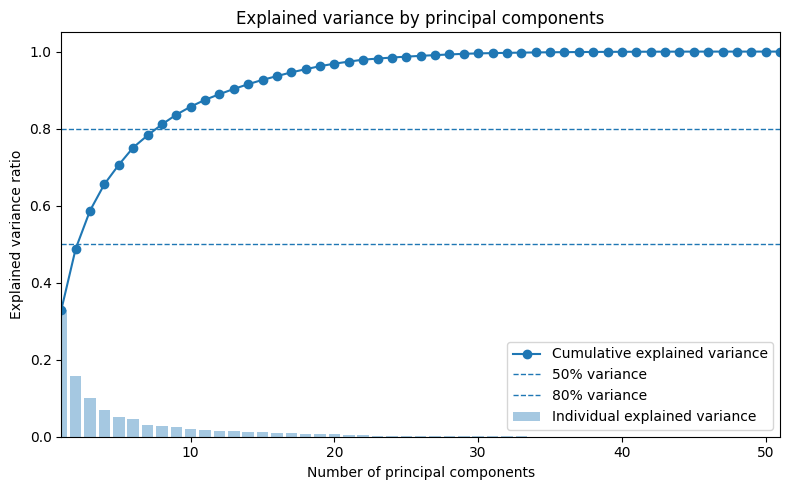

In [34]:

# Explained variance
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cum_explained) + 1),
    cum_explained,
    marker="o",
    label="Cumulative explained variance"
)
plt.bar(
    range(1, len(explained) + 1),
    explained,
    alpha=0.4,
    label="Individual explained variance"
)

# reference lines
plt.axhline(0.5, linestyle="--", linewidth=1, label="50% variance")
plt.axhline(0.8, linestyle="--", linewidth=1, label="80% variance")

plt.xlabel("Number of principal components")
plt.ylabel("Explained variance ratio")
plt.title("Explained variance by principal components")
plt.xlim(1, len(explained))
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
# compute loadings


# Names for PCs
pc_names = [f"PC{i+1}" for i in range(pca.n_components_)]

# Component weights
component_weights = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=pc_names
)

# PCA loadings

loadings = pd.DataFrame(
    pca.components_.T * np.sqrt(pca.explained_variance_),
    index=feature_cols,
    columns=pc_names
)

print("Component weights:")
print(component_weights.head())

print("\nLoadings:")
print(loadings.head())

Component weights:
                   PC1       PC2       PC3       PC4       PC5       PC6  \
HR_TD_Mean    0.007559  0.044473  0.067683  0.114151 -0.270668  0.181853   
HR_TD_Median  0.010250  0.044201  0.069602  0.146689 -0.233283  0.194145   
HR_TD_std    -0.007229  0.007451  0.067281 -0.060966 -0.233571 -0.022043   
HR_TD_Min     0.007728  0.029243  0.019662  0.105748 -0.141578  0.190042   
HR_TD_Max    -0.002187  0.025018  0.057879  0.007909 -0.290043  0.103749   

                   PC7       PC8       PC9      PC10  ...      PC42      PC43  \
HR_TD_Mean    0.243696 -0.235924  0.000252  0.021734  ...  0.286637  0.068686   
HR_TD_Median  0.240275 -0.261949  0.076425  0.022542  ... -0.385717 -0.112992   
HR_TD_std    -0.071365 -0.016427 -0.385968 -0.009016  ... -0.056900 -0.002531   
HR_TD_Min     0.285541 -0.227012  0.187421  0.048134  ... -0.180291 -0.073335   
HR_TD_Max     0.116399 -0.138819 -0.251419  0.017486  ... -0.279474 -0.137234   

                  PC44      PC45     

In [36]:
for pc in ["PC1", "PC2", "PC3"]:
    print(f"\nTop absolute loadings for {pc}:")
    print(loadings[pc].sort_values(key=np.abs, ascending=False).head(10))




Top absolute loadings for PC1:
EDA_TD_P_Slope         3.871851
EDA_TD_P_Slope_mean    0.786792
EDA_TD_T_Slope        -0.520797
EDA_TD_T_Slope_mean   -0.510649
EDA_TD_P_Median        0.447902
EDA_TD_P_Min          -0.400585
EDA_TD_P_Skew         -0.384162
EDA_TD_P_AUC           0.369548
EDA_TD_P_ReT          -0.353162
EDA_TD_P_Kurtosis     -0.346838
Name: PC1, dtype: float64

Top absolute loadings for PC2:
EDA_TD_T_Slope         1.980513
EDA_TD_T_Slope_mean    1.826315
EDA_TD_T_AUC           0.411108
EDA_TD_T_Min           0.379727
EDA_TD_P_Median        0.360321
EDA_TD_P_ReT          -0.300535
EDA_TD_P_Peaks         0.272744
EDA_TD_P_Kurtosis     -0.244311
EDA_TD_P_Skew         -0.242815
EDA_TD_P_Mean          0.233665
Name: PC2, dtype: float64

Top absolute loadings for PC3:
EDA_TD_P_Slope         0.726080
EDA_TD_T_AUC          -0.666180
EDA_TD_T_Min          -0.632534
EDA_TD_P_AUC          -0.468003
EDA_TD_T_Mean         -0.452162
EDA_TD_T_Median       -0.449170
EDA_TD_T_Slope_mean 

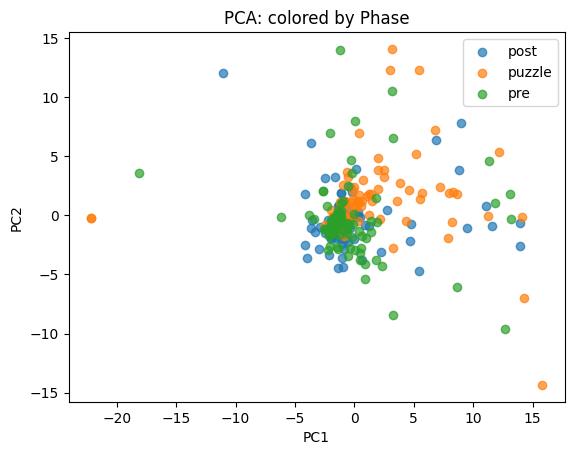

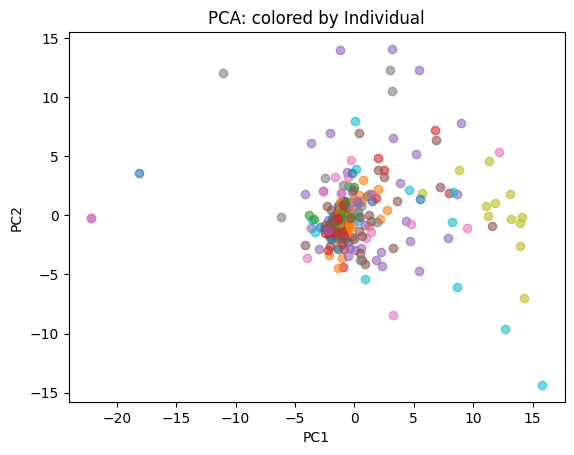

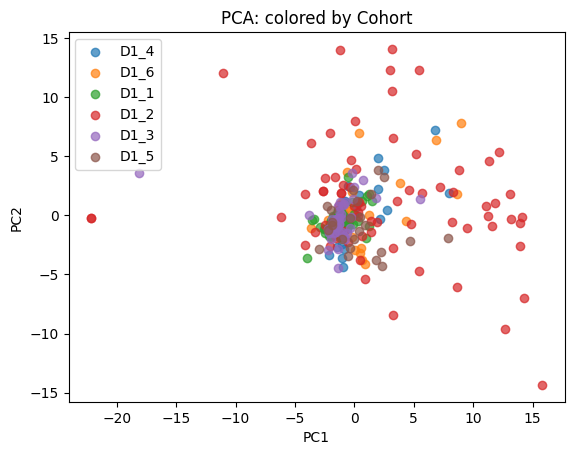

In [37]:
import matplotlib.pyplot as plt


pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Phase": df["Phase_clean"].values,
    "Round": df["Round_num"].values,
    "Individual": df["Individual"].values,
    "Puzzler": df["Puzzler"].values,
    "Cohort": df["Cohort"].values,
    "Frustrated": df["Frustrated"]
})

for phase in pca_df["Phase"].unique():
    subset = pca_df[pca_df["Phase"] == phase]
    plt.scatter(subset["PC1"], subset["PC2"], label=phase, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: colored by Phase")
plt.legend()
plt.show()
for individual in pca_df["Individual"].unique():
    subset = pca_df[pca_df["Individual"] == individual]
    plt.scatter(subset["PC1"], subset["PC2"], alpha=0.6)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: colored by Individual")
plt.show()
for cohort in pca_df["Cohort"].unique():
    subset = pca_df[pca_df["Cohort"] == cohort]
    plt.scatter(subset["PC1"], subset["PC2"], label=cohort, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: colored by Cohort")
plt.legend()
plt.show()